
<div style="
    color: black;
    font-size: 50px;
    font-family: cursive;
">
Real-Time Hand Gesture Recognition System
</div>

![Game Demo](akisa.png)


<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
~~~~~~ Cell 1 — Install and Download Dataset ~~~~~~</div>

In [14]:
import kagglehub
path = kagglehub.dataset_download("sanikamal/rock-paper-scissors-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'rock-paper-scissors-dataset' dataset.
Dataset path: /kaggle/input/rock-paper-scissors-dataset


<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
 ~~~~~~ Cell 2 — Setup Paths ~~~~~~
</div>

In [15]:
base_path = path + "/Rock-Paper-Scissors"
train_dir = base_path + "/train"
test_dir  = base_path + "/test"

import os
for split, d in [("train", train_dir), ("test", test_dir)]:
    print(f"\n{split.upper()}:")
    for cls in sorted(os.listdir(d)):
        count = len(os.listdir(os.path.join(d, cls)))
        print(f"  {cls}: {count} images")


TRAIN:
  paper: 840 images
  rock: 840 images
  scissors: 840 images

TEST:
  paper: 124 images
  rock: 124 images
  scissors: 124 images



<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
~~~~~~ Cell 3 — Load dataset ~~~~~~
</div>

In [16]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

# IMPORTANT — save class names before caching
CLASS_NAMES = train_ds.class_names
print("Class names:", CLASS_NAMES)

train_ds = train_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 2520 files belonging to 3 classes.
Found 372 files belonging to 3 classes.
Class names: ['paper', 'rock', 'scissors']



<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
~~~~~~ Cell 4 — Build and train model ~~~~~~
</div>

In [17]:
import tensorflow as tf

# Use MobileNetV2 — much better than training from scratch
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# Augmentation to handle real webcam conditions
x = tf.keras.layers.RandomFlip("horizontal")(inputs)
x = tf.keras.layers.RandomRotation(0.2)(x)
x = tf.keras.layers.RandomZoom(0.2)(x)
x = tf.keras.layers.RandomBrightness(0.3)(x)
x = tf.keras.layers.RandomContrast(0.3)(x)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_1             │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
~~~~~~ Cell 5 — Train ~~~~~~</div>

In [18]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.8036 - loss: 0.5094 - val_accuracy: 0.7930 - val_loss: 0.5628
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9440 - loss: 0.1872 - val_accuracy: 0.8387 - val_loss: 0.4290
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9619 - loss: 0.1318 - val_accuracy: 0.8199 - val_loss: 0.4496



<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
~~~~~~ Cell 6 — Plot training results ~~~~~~</div>

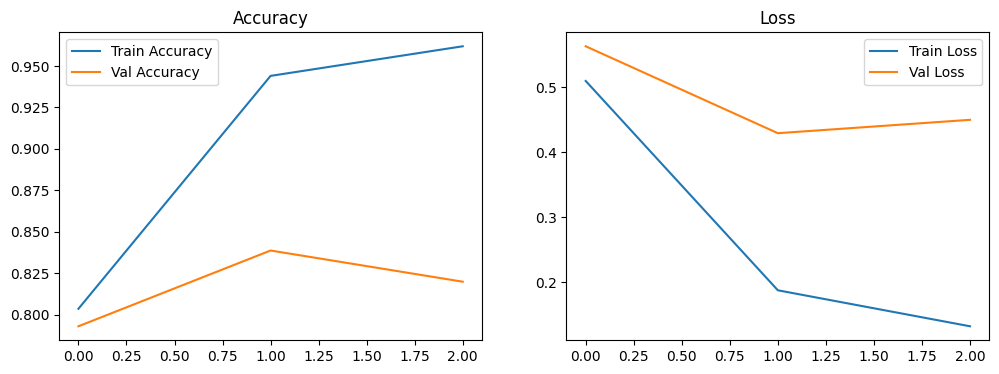

Best val accuracy: 0.8387096524238586


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],    label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],    label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()
print("Best val accuracy:", max(history.history['val_accuracy']))


<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
~~~~~~ Cell 7 — Verify model works on training images ~~~~~~</div>

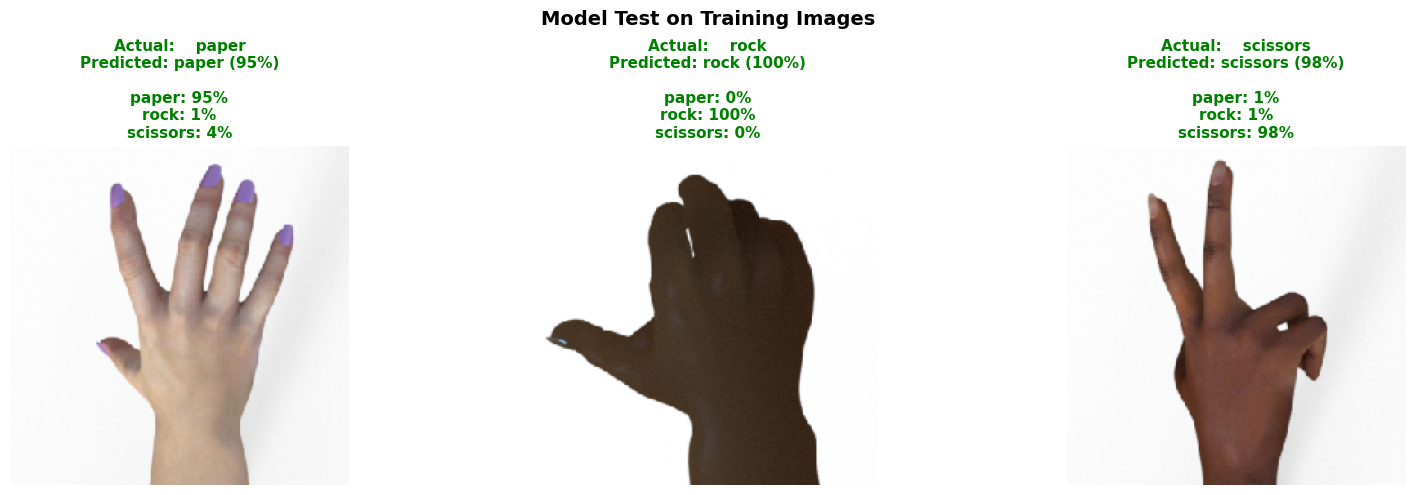

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(train_dir, cls)
    img_file = os.listdir(cls_dir)[0]
    img_path = os.path.join(cls_dir, img_file)

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_input = np.expand_dims(img_array, axis=0)  # NO /255 for MobileNetV2

    pred = model.predict(img_input, verbose=0)[0]
    predicted = CLASS_NAMES[np.argmax(pred)]
    confidence = np.max(pred) * 100

    # Green title if correct, red if wrong
    color = 'green' if predicted == cls else 'red'

    axes[i].imshow(img)
    axes[i].set_title(
        f"Actual:    {cls}\n"
        f"Predicted: {predicted} ({confidence:.0f}%)\n\n"
        f"{CLASS_NAMES[0]}: {pred[0]:.0%}\n"
        f"{CLASS_NAMES[1]}: {pred[1]:.0%}\n"
        f"{CLASS_NAMES[2]}: {pred[2]:.0%}",
        fontsize=11,
        color=color,
        fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle("Model Test on Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
~~~~~~ Cell 8 — Save model and class names ~~~~~~
</div>

In [21]:
import json

model.save("rps_final.keras")

with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)

print("✅ Saved!")
print("Class names:", CLASS_NAMES)

✅ Saved!
Class names: ['paper', 'rock', 'scissors']



<div style="
    color: black;
    font-size: 30px;
    font-family: cursive;
">
~~~~~~ Cell 9 — Load model fresh ~~~~~~
</div>

In [22]:
import tensorflow as tf
import json
import numpy as np
from PIL import Image
from base64 import b64decode
import io
import random
from google.colab.output import eval_js

model = tf.keras.models.load_model("rps_final.keras")

with open("class_names.json") as f:
    CLASS_NAMES = json.load(f)

print("✅ Model loaded")
print("Classes:", CLASS_NAMES)

def get_winner(user, computer):
    if user == computer:
        return "🤝 Draw"
    if (user == "rock"     and computer == "scissors") or \
       (user == "paper"    and computer == "rock")     or \
       (user == "scissors" and computer == "paper"):
        return "🎉 You Win!"
    return "💻 Computer Wins!"

✅ Model loaded
Classes: ['paper', 'rock', 'scissors']


/tmp/ipykernel_3011/2940608591.py:109: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


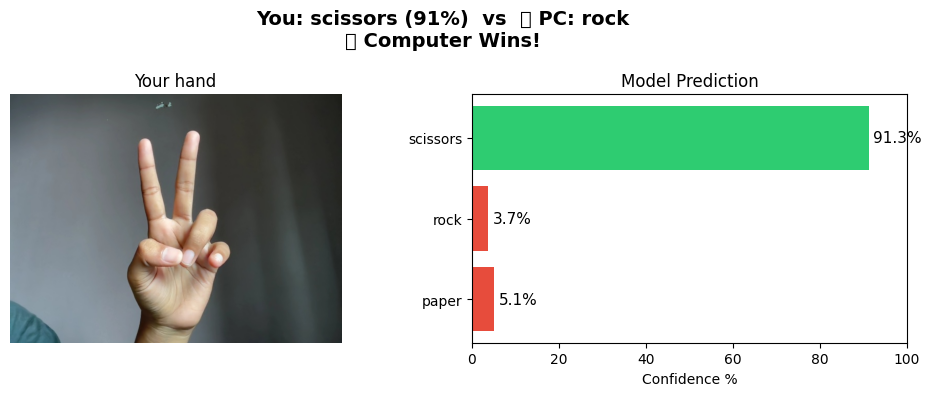


  👤 You:      scissors (91%)
  💻 Computer: rock
  🏆 Result:   💻 Computer Wins!


In [25]:
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import numpy as np
import io
import random
import matplotlib.pyplot as plt

def capture_and_predict():
    data_url = eval_js('''
        new Promise(async (resolve) => {
            // Remove any old elements
            document.querySelectorAll('.rps-el').forEach(e => e.remove());

            const msg = document.createElement('div');
            msg.className = 'rps-el';
            msg.style = 'font-size:22px; font-weight:bold; margin:6px 0;';
            msg.innerText = '⏳ Starting camera...';
            document.body.appendChild(msg);

            const video = document.createElement('video');
            video.className = 'rps-el';
            video.style = 'width:400px; display:block; border-radius:10px; margin:8px 0;';
            video.autoplay = true;
            video.playsInline = true;
            document.body.appendChild(video);

            try {
                const stream = await navigator.mediaDevices.getUserMedia({
                    video: { width: 640, height: 480 }
                });
                video.srcObject = stream;
                await video.play();

                // Countdown
                for (let i = 3; i > 0; i--) {
                    msg.innerText = "✋ Show your hand in... " + i;
                    await new Promise(r => setTimeout(r, 1000));
                }
                msg.innerText = "📸 Capturing...";
                await new Promise(r => setTimeout(r, 200));

                const canvas = document.createElement('canvas');
                canvas.width  = video.videoWidth  || 640;
                canvas.height = video.videoHeight || 480;
                canvas.getContext('2d').drawImage(video, 0, 0);

                stream.getTracks().forEach(t => t.stop());

                // Show captured image briefly
                canvas.style = 'width:400px; display:block; border-radius:10px; margin:8px 0;';
                canvas.className = 'rps-el';
                document.body.appendChild(canvas);
                video.remove();
                msg.innerText = "✅ Got it! Processing...";

                setTimeout(() => {
                    document.querySelectorAll('.rps-el').forEach(e => e.remove());
                }, 3000);

                resolve(canvas.toDataURL('image/jpeg', 0.95));

            } catch(err) {
                msg.innerText = '❌ Camera error: ' + err.message;
                resolve('error');
            }
        })
    ''')

    if data_url == 'error' or not data_url:
        print("❌ Camera failed. Allow camera access and try again.")
        return

    # Decode image
    img_bytes   = b64decode(data_url.split(',')[1])
    img         = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    img_resized = img.resize((224, 224))
    img_array   = np.expand_dims(np.array(img_resized), axis=0)

    # Predict
    pred        = model.predict(img_array, verbose=0)[0]
    confidence  = float(np.max(pred) * 100)
    user        = CLASS_NAMES[int(np.argmax(pred))]
    computer    = random.choice(CLASS_NAMES)
    result      = get_winner(user, computer)

    # Show result
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left — captured image
    axes[0].imshow(img)
    axes[0].set_title("Your hand", fontsize=12)
    axes[0].axis('off')

    # Right — prediction bar chart
    colors = ['#2ecc71' if n == user else '#e74c3c' for n in CLASS_NAMES]
    bars = axes[1].barh(CLASS_NAMES, pred * 100, color=colors)
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel('Confidence %')
    axes[1].set_title('Model Prediction', fontsize=12)
    for bar, score in zip(bars, pred):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{score*100:.1f}%', va='center', fontsize=11)

    plt.suptitle(
        f"You: {user} ({confidence:.0f}%)  vs  💻 PC: {computer}\n{result}",
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*35}")
    print(f"  👤 You:      {user} ({confidence:.0f}%)")
    print(f"  💻 Computer: {computer}")
    print(f"  🏆 Result:   {result}")
    print(f"{'='*35}")

# Run it
capture_and_predict()